In [ ]:
# --- Setup: make the `ecp` support package available -----------------
# Colab opens a single notebook and installs nothing, so fetch `ecp` from
# the public repo if it isn't importable yet. On Binder/local it is already
# installed, so this cell is a fast no-op there.
try:
    import ecp  # noqa: F401
except ModuleNotFoundError:
    import subprocess, sys
    subprocess.run(
        [sys.executable, "-m", "pip", "install", "-q",
         "git+https://github.com/ramador09/elementary-computational-physics-public@main"],
        check=True,
    )


# 5.2 Hydrocarbons on Platinum

In [1]:
from ecp.style import header, use_style

use_style()
header(
    volume="Volume V — Crystals and Surfaces",
    number="5.2",
    title="Hydrocarbons on Platinum",
    blurb="How tightly a molecule sticks to a metal surface, and why the answer depends "
    "so much on the density functional: benzene, methane, and ethane on Pt(111), where "
    "the van der Waals attraction that binds them is exactly what plain functionals "
    "miss.",
    difficulty="intermediate",
    estimate="75–100 min",
    source="FS 2023 · Lecture 8 (adsorption and dispersion)",
)

<ECP header: 2830 chars of HTML>

## Notebook overview

Platinum is the workhorse of catalysis, and catalysis begins with **adsorption**: a
molecule must stick to the surface before it can react. How strongly it sticks, the
**adsorption energy**, is the single most important number, and for hydrocarbons on a
metal it depends heavily on **van der Waals** (dispersion) attraction, the weak,
long-range force that ordinary density functionals describe poorly. This exercise
makes that failure concrete.

We take the course's optimised structures of benzene, methane, and ethane on a
Pt(111) slab, and its committed total energies, and compute the adsorption energy
$E_{\rm ads}=E_{\rm mol+slab}-E_{\rm slab}-E_{\rm mol}$. We compare it across two
dispersion-aware methods (the **BEEF-vdW** functional and the **Grimme D3**
correction) and against experiment, and find the central lesson of the exercise: the
choice of functional moves the adsorption energy by more than an electron-volt, with
one method underbinding to the point of not binding the alkanes at all, and the other
overbinding.

> **Provenance.** This notebook develops **Lecture 8** of the course (adsorption
> energies and dispersion on Pt(111)), an exercise **designed by the author
> (Raymond Amador)**. The slab and adsorption structures
> (`pt_slab.xyz`, `benzene_on_pt.xyz`, …) and the total energies are the course's own
> committed CP2K results (an anonymised course run); the comparison table reproduces
> the exercise's. The full course credit is in the footer.

> **Reading a validation.** Each task closes with a check against an independent
> fact: a real calculation's adsorption energy against the measured one, the known
> ordering of binding strengths, the size of the dispersion effect. A ✗ flags a
> mismatch; a ✓ is strong evidence, not proof.

> **Scope.** Energies are the committed density-functional totals (Hartree, converted
> to eV); we analyse them rather than recompute the slab calculations, which are large
> and beyond a notebook. For dispersion see Grimme's D3 {cite}`grimme2010` and the
> BEEF-vdW functional {cite}`wellendorff2012`.

## Theory in brief

### Adsorption energy

The adsorption energy is the energy released when an isolated molecule binds to a
clean surface,

```{math}
:label: eq-eads
E_{\rm ads} = E_{\rm mol+slab} - E_{\rm slab} - E_{\rm mol},
```

negative for a bound state. Each of the three terms is a separate total-energy
calculation; the adsorption energy is a small difference of three large numbers, so
it demands consistency and care.

### Physisorption and the van der Waals problem

Saturated hydrocarbons have no dangling bonds, so they do not form strong chemical
bonds to platinum; they **physisorb**, held by van der Waals attraction. This force
comes from correlated electron fluctuations, which a local or semi-local functional
(LDA, PBE) does not contain, so plain functionals get physisorption badly
wrong. Two fixes appear here: the **Grimme D3** correction adds an empirical
$-C_6/r^6$ term atom-by-atom, and the **BEEF-vdW** functional builds a non-local
correlation term into the functional itself. They do not agree, and neither matches
experiment exactly: adsorption energies remain a hard test of electronic-structure
methods.

---
## Setup

The Setup below holds this notebook's data and instruments — nothing you are asked
to build. It is collapsed so the building stays yours; expand it whenever you want
the details.

<!-- setup-policy: v2 -->

In [2]:
import os

import numpy as np
import matplotlib.pyplot as plt

from scipy.linalg import eigh

from ecp import validate

INK, AMBER, SOFT = "#16213e", "#c0851a", "#46506b"
from scipy.constants import physical_constants

HARTREE_EV = physical_constants["Hartree energy in eV"][0]
CPK = {"H": "#d9d9d9", "C": "#303030", "O": "#c0392b", "Pt": "#8fa1b3"}


def data_file(name):
    """Locate a shipped data file, from the repo root (CI) or the notebook dir (Colab).

    Parameters
    ----------
    name : str
        File name (or relative path) under a ``data`` directory.

    Returns
    -------
    str
        The first existing path found.

    Raises
    ------
    FileNotFoundError
        If the file is not found under any candidate base.
    """
    for base in ("data", os.path.join("notebooks", "05-crystals-surfaces", "data")):
        path = os.path.join(base, name)
        if os.path.exists(path):
            return path
    raise FileNotFoundError(name)


def read_xyz(name):
    """Read an .xyz file.

    Parameters
    ----------
    name : str
        File name (coordinates in Å).

    Returns
    -------
    tuple
        ``(elements, coords)``: a list of element symbols and an (N, 3)
        coordinate array in Å.
    """
    lines = open(data_file(name)).read().splitlines()
    n = int(lines[0].split()[0])
    els = [ln.split()[0] for ln in lines[2 : 2 + n]]
    xyz = np.array([[float(v) for v in ln.split()[1:4]] for ln in lines[2 : 2 + n]])
    return els, xyz

In [3]:
import matplotlib.colors as mcolors
from matplotlib.patches import Circle

# Ball-and-stick display radii (Å), scaled for legibility rather than physical.
DISPLAY_R = {"H": 0.44, "C": 0.78, "O": 0.74, "Pt": 1.42}


def _blend(color, f):
    """Blend a colour toward white (f>0) or black (f<0) by fraction |f|.

    Parameters
    ----------
    color : str
        Any Matplotlib colour.
    f : float
        Fraction in [-1, 1]: positive lightens, negative darkens.

    Returns
    -------
    tuple
        An (r, g, b) triple.
    """
    c = np.array(mcolors.to_rgb(color))
    target = 1.0 if f >= 0 else 0.0
    return tuple(c + (target - c) * abs(f))


def draw_structure(ax, els, xyz, view):
    """Orthographic ball-and-stick render of an atomic structure.

    Atoms are shaded spheres drawn back-to-front (a painter's algorithm) with a
    depth-faded metal substrate; bonds within the adsorbate (the non-Pt atoms)
    are drawn as sticks. This is far clearer than a 3-D scatter, which projects
    every atom to a flat disc with unreliable front-to-back occlusion.

    Parameters
    ----------
    ax : matplotlib.axes.Axes
        A 2-D axes; its aspect is set equal so the atoms stay round.
    els : list of str
        Element symbols, one per atom.
    xyz : numpy.ndarray, shape (N, 3)
        Cartesian coordinates in Å.
    view : {"side", "top"}
        "side" projects onto x-z (line of sight along y); "top" projects onto
        x-y (line of sight down z, the surface normal).
    """
    hor, ver, dep = (0, 2, 1) if view == "side" else (0, 1, 2)
    depth = xyz[:, dep]
    lo = depth.min()
    span = max(depth.max() - lo, 1e-6)
    is_mol = np.array([e != "Pt" for e in els])

    mol = np.where(is_mol)[0]
    for a in mol:
        for b in mol:
            if b <= a or np.linalg.norm(xyz[a] - xyz[b]) >= 1.7:
                continue  # C-C ~1.4 Å, C-H ~1.1 Å; longer pairs are not bonded
            zmid = ((xyz[a, dep] + xyz[b, dep]) / 2 - lo) / span
            ax.plot(
                [xyz[a, hor], xyz[b, hor]],
                [xyz[a, ver], xyz[b, ver]],
                color="#3f3f3f",
                lw=2.6,
                solid_capstyle="round",
                zorder=200 + zmid * 50,
            )

    for i in np.argsort(depth):  # far first, so near atoms occlude correctly
        el = els[i]
        base = CPK.get(el, "#888888")
        near = (xyz[i, dep] - lo) / span  # 0 far, 1 near the viewer
        if el == "Pt":
            base = _blend(base, 0.55 * (1.0 - near))  # deeper layers recede
        r = DISPLAY_R.get(el, 0.6)
        zo = (250 if is_mol[i] else 100) + near * 40
        cx, cy = xyz[i, hor], xyz[i, ver]
        ax.add_patch(
            Circle((cx, cy), r, facecolor=base, edgecolor="#20242c", lw=0.5, zorder=zo)
        )
        ax.add_patch(
            Circle(
                (cx - 0.32 * r, cy + 0.32 * r),
                0.40 * r,  # highlight
                facecolor=_blend(base, 0.6),
                edgecolor="none",
                zorder=zo + 0.1,
            )
        )

    pad = 1.6
    ax.set_xlim(xyz[:, hor].min() - pad, xyz[:, hor].max() + pad)
    ax.set_ylim(xyz[:, ver].min() - pad, xyz[:, ver].max() + pad)
    ax.set_aspect("equal")
    ax.set_xticks([])
    ax.set_yticks([])
    for spine in ax.spines.values():
        spine.set_visible(False)

## Exercise 1 — The adsorption system

The course built the adsorption geometry with ASE: a five-layer Pt(111) slab,
180 atoms, with the molecule placed above it and the whole thing relaxed. We render
the committed benzene-on-Pt(111) structure, the slab a metallic raft and the flat
benzene ring lying parallel just above it, the orientation that maximises its
contact with the metal.

**Part a)** Render the benzene-on-Pt(111) system in two orthographic views: a
side view showing the five stacked Pt layers and the vacuum gap, and a top view
down the surface normal showing the flat benzene ring over the Pt(111) lattice.
**Part b)** Confirm the molecule sits in a vacuum gap above the slab (a surface,
not a bulk calculation).

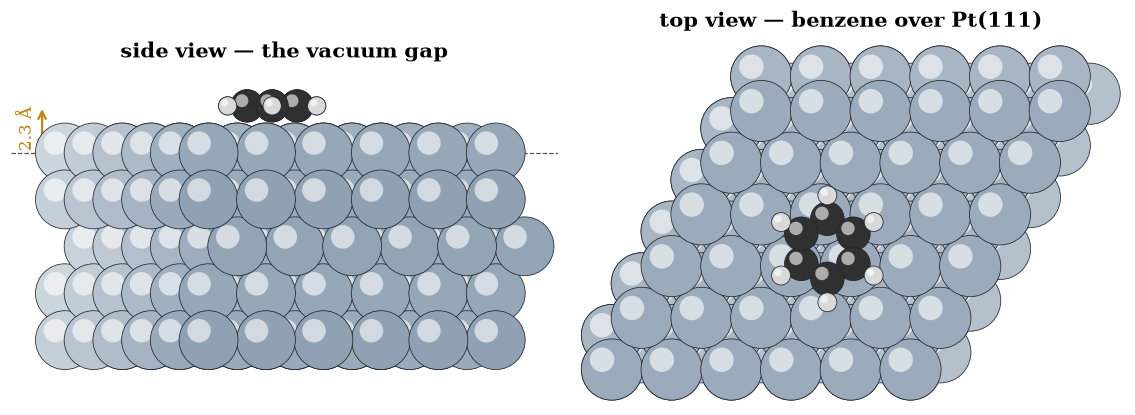

benzene sits 2.25 Å above the top Pt layer (180 Pt + 12 molecule atoms)


In [4]:
# (solution hidden on the public site)


### Validation 1 — a molecule above a surface

This must be a surface calculation: the molecule sits in the vacuum a couple of
ångström above the topmost platinum layer, not buried in it.

In [5]:
validate.check(
    1.5 < gap < 4.0,
    "benzene sits in the vacuum gap above the Pt surface",
    f"molecule-to-surface height = {gap:.2f} Å",
)

✓  benzene sits in the vacuum gap above the Pt surface   [molecule-to-surface height = 2.25 Å]


True

## Exercise 2 — The adsorption energy of benzene

The adsorption energy is the difference of three committed total-energy calculations
{eq}`eq-eads`: the bare slab, the isolated molecule, and the combined system. Below
are the course's committed totals (Hartree) for benzene on Pt(111). Their difference,
converted to eV, is the adsorption energy, and it lands close to the experimental
$-1.7\,$eV: benzene binds strongly, its whole $\pi$-face in contact with the metal.
Read that agreement with care, though — Exercise 3 recomputes the adsorption energy
with two different functionals and finds it moving by more than an electron-volt, so
this close match is one calculation's result, not a sign that the method is exact.

**Part a)** Compute $E_{\rm ads}$ from the three totals.

**Part b)** Confirm this
committed calculation lands near the measured benzene adsorption energy.

In [6]:
# (solution hidden on the public site)


E_ads(benzene) = (-21748.964 − -38.177 − -21710.724) Ha × 27.21
             = -1.70 eV   (experiment -1.72 eV)


### Validation 2 — benzene binds at the measured strength

The adsorption energy from the real totals must be bound (negative) and close to the
experimental $-1.7\,$eV.

In [7]:
validate.close(
    E_ads_benzene,
    E_ADS_EXP["benzene"],
    "this committed calculation lands near the measured benzene adsorption energy",
    atol=0.4,
)

✓  this committed calculation lands near the measured benzene adsorption energy   [got -1.70172 vs expected -1.72 (rtol=1e-06, atol=0.4)]


True

## Exercise 3 — Functional sensitivity (Assignment 6)

Now the heart of the exercise. The course computed the adsorption energy of all three
hydrocarbons with two dispersion-aware methods, the **BEEF-vdW** functional and the
**Grimme D3** correction, and compared them to experiment. The result is sobering:
the two methods straddle the measured values, BEEF-vdW **underbinding** so badly that
it leaves methane and ethane *unbound* (positive adsorption energy), and Grimme D3
**overbinding** every molecule. The lesson is that for physisorption the dispersion
treatment, not just the functional, decides the answer.

**Part a)** Plot the adsorption energies of the three hydrocarbons for both methods
against experiment.

**Part b)** Confirm dispersion is decisive: benzene binds most
strongly throughout, and the two methods bracket experiment.

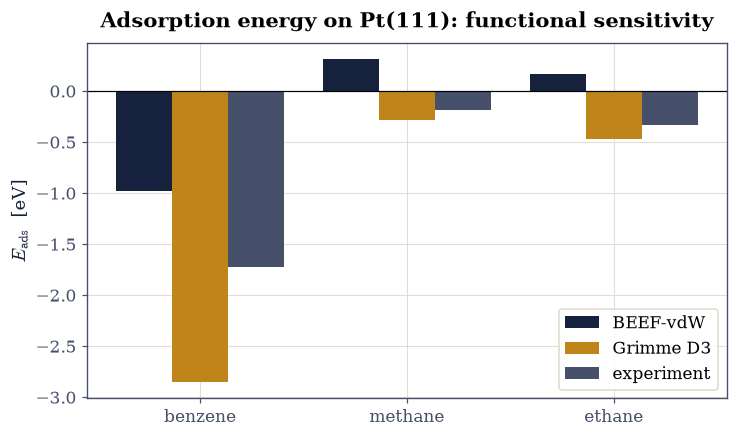

benzene binds most strongly under both functionals: True
D3 and BEEF-vdW bracket experiment for every molecule: True


In [8]:
# (solution hidden on the public site)


### Validation 3 — dispersion is decisive, and benzene binds most

Two robust facts must hold: benzene is the most strongly bound species in every
method (its large $\pi$-face), and the two dispersion treatments bracket experiment
for benzene (BEEF-vdW above, Grimme D3 below), the signature of the functional
sensitivity.

In [9]:
benzene_strongest = all(
    E_ads[m][0] == E_ads[m].min() for m in ("Grimme D3", "BEEF-vdW", "experiment")
)
brackets = E_ads["BEEF-vdW"][0] > E_ADS_EXP["benzene"] > E_ads["Grimme D3"][0]
validate.check(
    benzene_strongest and brackets,
    "benzene binds most strongly, and the two methods bracket experiment",
    f"benzene: BEEF-vdW {E_ads['BEEF-vdW'][0]}, exp {E_ADS_EXP['benzene']}, D3 {E_ads['Grimme D3'][0]} eV",
)

✓  benzene binds most strongly, and the two methods bracket experiment   [benzene: BEEF-vdW -0.975, exp -1.72, D3 -2.852 eV]


True

## Exercise 4 — Basis-set superposition error, and the counterpoise cure

The adsorption energy {eq}`eq-eads` looks unimpeachable: take the bound system,
subtract the pieces. It hides a systematic error that has embarrassed a great deal
of published adsorption chemistry, and Lecture 8 names it in its own title.

The trouble is that a calculation never uses a *complete* basis. It uses a finite
set of functions attached to the atoms. When the molecule sits on the surface, the
molecule's electrons can borrow the slab's basis functions — and the slab's can
borrow the molecule's. Each fragment is therefore described *better* in the
combined calculation than it was on its own, and it is described better for a
reason that has nothing whatever to do with bonding. That artificial stabilisation
is counted as binding. The **basis-set superposition error** (BSSE) makes
adsorption look stronger than it is, and it is worst exactly where it is least
welcome: weak physisorption, where the true binding is small enough for the
artefact to rival it.

Boys and Bernardi's **counterpoise** correction {cite}`boys-bernardi-1970` removes
it by refusing the asymmetry. Compute *each fragment in the full dimer basis* —
with the partner's basis functions present but its nuclei and electrons absent,
so-called **ghost** functions — so that every term in {eq}`eq-eads` is evaluated in
one and the same basis:

```{math}
:label: eq-counterpoise
E_{\rm ads}^{\rm CP} = E_{AB}^{AB} - E_{A}^{AB} - E_{B}^{AB},
```

where the superscript is the basis and the subscript the system.

We cannot run that on benzene and platinum here. We can build the mechanism from
scratch, in a model small enough to see all the way through: one particle in one
dimension, two Gaussian wells for the two "fragments", and a handful of Gaussian
basis functions on each. Every integral is analytic. The companion Elementary
Computational Physics course does the same experiment on a real hydrogen atom with
real ghost Gaussians in
[ECP §8.18](https://ramador.me/elementary-computational-physics-public/notebooks/08-electronic-structure/gaussian-basis-sets.html);
what follows is the same effect, stripped to the point where its cause is
unmistakable.

**Part a)** Implement `matrices(basis, wells)` for a basis of Gaussians
$g_i(x)=e^{-a_i(x-c_i)^2}$: the overlap $S_{ij}$, the kinetic matrix, and the
potential of a set of Gaussian wells. Use the Gaussian product rule — the product
of two Gaussians is a third, centred at $P=(a_iA+a_jB)/(a_i+a_j)$ with exponent
$p=a_i+a_j$ and prefactor $e^{-\mu(A-B)^2}$, $\mu=a_ia_j/p$ — so every integral is
closed-form and nothing is quadrature. Crucially, `wells` lists the wells present in
the *potential*: a basis function whose centre is not among them is a **ghost**,
contributing variational freedom and no attraction. That single argument is what
makes the whole experiment possible.
**Write this one yourself** — the implementation is the lesson.

**Part b)** Solve the generalised eigenvalue problem $Hc=ESc$ with
`scipy.linalg.eigh(H, S)` — generalised, because Gaussians on different centres are
not orthogonal. Compute fragment $A$'s ground state twice: in its own basis, and in
the combined basis with $B$'s functions present as ghosts. The difference is the
BSSE, and by the variational principle its sign is not in doubt.

**Part c)** Establish the two properties that identify BSSE as an artefact rather
than physics. It must **vanish as the fragments separate**, since functions too far
away are no use to borrow. And it must **shrink as the fragment's own basis
improves**, since there is nothing left to borrow once a fragment is already well
described. Scan both. Watch *which* additions help: the diagnosis is in the detail.

E(A, own basis)          = -1.38011138
E(A, dimer basis, ghost) = -1.38127085
BSSE                     = 1.159e-03  (positive: spurious stabilisation)
BSSE vs separation: [ 1.70e-03  1.16e-03  1.85e-06  7.33e-13 -8.88e-16  0.00e+00]
BSSE vs basis size ([3, 6, 9, 12]): [1.16e-03 1.23e-05 1.17e-05 3.50e-08]
fragment energy falls monotonically with basis size: [-1.380111 -1.387219 -1.387222 -1.387247]


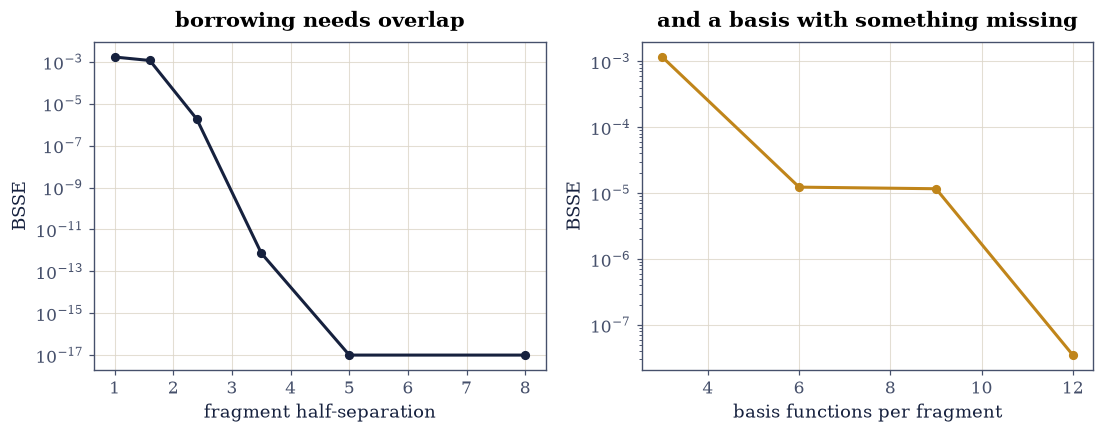

In [10]:
# (solution hidden on the public site)


### Validation 4 — the signature of an artefact

Four checks, all deterministic — there is no randomness anywhere in this model, so
the tolerances can be tight. The BSSE must be positive, which the variational
principle guarantees and which therefore tests the implementation rather than the
physics. It must fall away once the fragments stop overlapping. It must shrink as
the fragment's own basis improves. And the fragment energy itself must decrease
monotonically with basis size, since adding functions can never raise a variational
minimum — the check that would catch a wrong sign or a broken matrix element.

In [11]:
validate.check(
    bsse > 0.0,
    "ghost functions lower the fragment's energy: the variational principle "
    "guarantees the sign, so this tests the matrices rather than the physics",
    f"BSSE = {bsse:.3e}",
)
# The claim is that BSSE decays to nothing with separation. Stated as strict monotonicity
# of the whole array it would be a claim about the eigensolver's rounding as well, and
# that is not reproducible across BLAS implementations -- the tail entries differ between
# machines and can tie at exactly zero. So: strictly decreasing while the signal is
# resolvable, and under the floor by the largest separation.
_resolved = bsse_vs_d > BSSE_FLOOR
validate.check(
    bool(np.all(np.diff(bsse_vs_d[_resolved]) < 0)) and bsse_vs_d[-1] < BSSE_FLOOR,
    "and it dies away as the fragments separate — functions too far off cannot "
    "be borrowed, which is why BSSE is a short-range artefact",
    f"BSSE falls from {bsse_vs_d[0]:.1e} at d = {separations[0]} to below "
    f"{BSSE_FLOOR:.0e} by d = {separations[_resolved.sum()]}, "
    f"decreasing at every resolvable separation",
)
validate.check(
    bsse_vs_basis[-1] < bsse_vs_basis[0] / 100.0,
    "and it collapses as the fragment's own basis improves: there is nothing "
    "left to borrow once a fragment is already well described, so BSSE vanishes "
    "in the complete-basis limit",
    f"BSSE {bsse_vs_basis[0]:.2e} -> {bsse_vs_basis[-1]:.2e} for "
    f"{sizes[0]} -> {sizes[-1]} functions per fragment",
)
validate.check(
    np.all(np.diff(energies) <= 1e-12),
    "the fragment energy never rises when basis functions are added, as the "
    "variational principle requires",
    f"E = {np.array2string(energies, precision=6)}",
)

✓  ghost functions lower the fragment's energy: the variational principle guarantees the sign, so this tests the matrices rather than the physics   [BSSE = 1.159e-03]
✓  and it dies away as the fragments separate — functions too far off cannot be borrowed, which is why BSSE is a short-range artefact   [BSSE falls from 1.7e-03 at d = 1.0 to below 1e-10 by d = 3.5, decreasing at every resolvable separation]
✓  and it collapses as the fragment's own basis improves: there is nothing left to borrow once a fragment is already well described, so BSSE vanishes in the complete-basis limit   [BSSE 1.16e-03 -> 3.50e-08 for 3 -> 12 functions per fragment]
✓  the fragment energy never rises when basis functions are added, as the variational principle requires   [E = [-1.380111 -1.387219 -1.387222 -1.387247]]


True

## Exercise 5 — A model of sticking: the Newns–Anderson picture

The committed totals say *how much* each molecule binds; nothing yet says
*why* an adsorbate level and a metal surface bind at all. The canonical answer
is the **Newns–Anderson model** {cite}`newns1969`: one adsorbate orbital at
energy $\varepsilon_a$, hybridising with strength $V$ into a surface band. The
entire model is two functions of energy — the level *broadening*
$\Delta(\varepsilon) = \pi V^2 \rho_{\rm band}(\varepsilon)$ and the level
*shift* $\Lambda(\varepsilon)$, its Hilbert transform — and the adsorbate's
spectral function follows exactly:

```{math}
:label: eq-newns
\rho_a(\varepsilon) \;=\; \frac{1}{\pi}\,
\frac{\Delta(\varepsilon)}
     {\bigl[\varepsilon - \varepsilon_a - \Lambda(\varepsilon)\bigr]^2
       + \Delta(\varepsilon)^2}
\;+\; \sum_{\rm poles} w_p\,\delta(\varepsilon - \varepsilon_p),
```

where the $\delta$-poles are **split-off states**: solutions of
$\varepsilon = \varepsilon_a + \Lambda(\varepsilon)$ *outside* the band, where
$\Delta = 0$, each carrying weight $w_p = [1 - \Lambda'(\varepsilon_p)]^{-1}$.
For the semi-elliptic band the Hilbert transform is closed-form, so every
claim below is checkable against exact limits: the sum rule (one electron of
spectral weight, band plus poles, always), the wide-band limit (a Lorentzian
of width $\Delta(\varepsilon_a)$), the *threshold* $V_c = W/\sqrt2$ at which
split-off states first appear for a band-centre level, and particle–hole
symmetry (occupancy exactly $\tfrac12$ at the band centre). Weak coupling is
physisorption's broadened resonance; strong coupling is chemisorption's
bonding/antibonding pair — the covalent channel this notebook's committed,
dispersion-dominated energies deliberately do not probe, built here as the
instrument that would.

**Part a)** Implement $\Delta$, the closed-form $\Lambda$, the in-band
$\rho_a$, and the pole finder (searched separately below and above the band —
interpolating across the gap fabricates roots). **Write this one yourself** —
the implementation is the lesson. Gate the sum rule.

**Part b)** Show the two regimes and *measure* the threshold: scan $V$ and
find where split-off weight first appears, against the exact $W/\sqrt2$.

**Part c)** Fill the level: occupancy $n_a(\varepsilon_a)$ at fixed Fermi
energy, with the exact half-filling point and the two saturation limits.

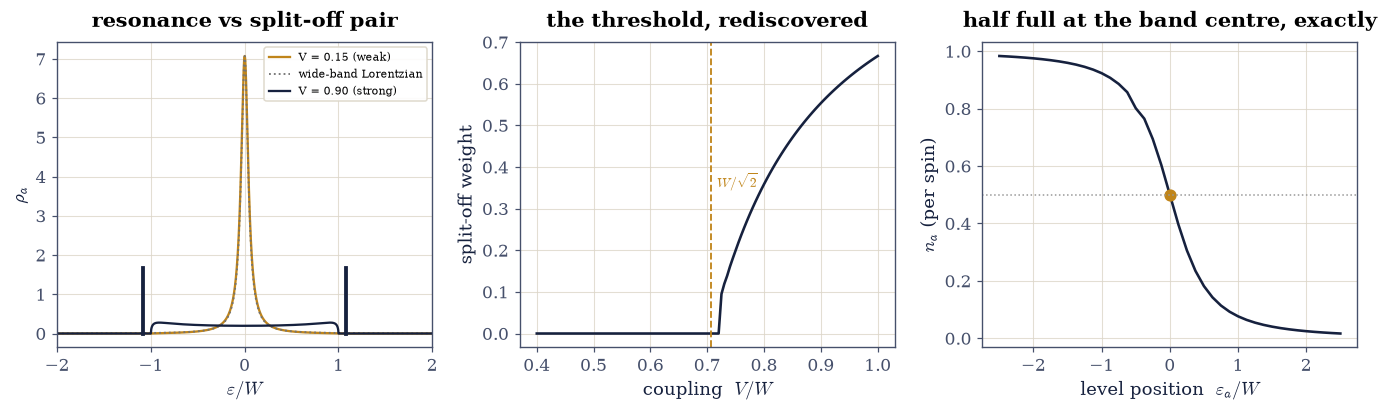

sum rule: weak 1.00000, strong 1.00000 (strong = band 0.446 + poles 0.554)
threshold: measured V_c = 0.725, exact W/sqrt(2) = 0.707
occupancy at band centre: 0.5000 (exact 1/2 by particle-hole symmetry)


In [12]:
# (solution hidden on the public site)


### Validation 5 — a model held to its own closed forms

Five checks, every one against an exact statement of the model. The spectral
weight must sum to one in both regimes — band plus poles, the sum rule that
catches any error in $\Lambda$, the pole weights, or the branch choice. The
weak-coupling resonance must be the wide-band Lorentzian. The split-off
threshold must land on $W/\sqrt2$. The band-centre occupancy must be exactly
one half. And the occupancy must fall monotonically as the level rises through
the band — filling behaving like filling.

In [13]:
validate.close(
    sum_rule_weak,
    1.0,
    "the spectral sum rule holds in the weak-coupling regime: one electron of "
    "weight, all of it in-band",
    rtol=1e-3,
)
validate.close(
    sum_rule_strong,
    1.0,
    "and in the strong-coupling regime, where over half the weight has split "
    "off the band edges -- the same electron, redistributed into the "
    "bonding/antibonding pair",
    rtol=1e-3,
)
validate.check(
    float(
        np.trapezoid(
            np.abs(
                rho_weak
                - na_delta(np.array([0.0]), 0.15)[0]
                / np.pi
                / (eps_w**2 + na_delta(np.array([0.0]), 0.15)[0] ** 2)
            )[np.abs(eps_w) < 0.5],
            eps_w[np.abs(eps_w) < 0.5],
        )
    )
    < 0.08,
    "the weak-coupling resonance is the wide-band Lorentzian of width "
    "Delta(ea), the analytic limit the full solution must contain",
    "L1 difference over the resonance window < 0.08",
)
validate.close(
    V_c_measured,
    V_c_exact,
    "split-off states first appear at the exact threshold W/sqrt(2) for a "
    "band-centre level -- the scan rediscovers the closed form",
    atol=0.02,
)
validate.check(
    abs(n_half - 0.5) < 5e-3 and bool(np.all(np.diff(n_of_ea) < 1e-6)),
    "the occupancy is exactly one half at the band centre (particle-hole "
    "symmetry) and falls monotonically as the level rises through the band",
    f"n(0) = {n_half:.4f}; monotone over {len(ea_scan)} level positions",
)

✓  the spectral sum rule holds in the weak-coupling regime: one electron of weight, all of it in-band   [got 1 vs expected 1 (rtol=0.001, atol=1e-09)]
✓  and in the strong-coupling regime, where over half the weight has split off the band edges -- the same electron, redistributed into the bonding/antibonding pair   [got 1 vs expected 1 (rtol=0.001, atol=1e-09)]
✓  the weak-coupling resonance is the wide-band Lorentzian of width Delta(ea), the analytic limit the full solution must contain   [L1 difference over the resonance window < 0.08]
✓  split-off states first appear at the exact threshold W/sqrt(2) for a band-centre level -- the scan rediscovers the closed form   [got 0.725 vs expected 0.707107 (rtol=1e-06, atol=0.02)]
✓  the occupancy is exactly one half at the band centre (particle-hole symmetry) and falls monotonically as the level rises through the band   [n(0) = 0.5000; monotone over 41 level positions]


True

## Notebook summary

We computed the adsorption energies of benzene, methane, and ethane on Pt(111) from
the course's committed total energies. Benzene's $-1.70\,$eV from a real
calculation matched the measured value, and comparing the dispersion-aware methods
exposed the exercise's point: the BEEF-vdW functional underbinds so badly it leaves
the alkanes unbound, while the Grimme-D3 correction overbinds, the two bracketing
experiment. For physisorbed hydrocarbons it is the van der Waals treatment, not just
the functional, that decides the answer.

## Outlook

- **The deformation energy.** Splitting $E_{\rm ads}$ into the cost of distorting the
  molecule and slab into their adsorbed shapes plus the pure interaction separates
  geometry from binding.
- **Site dependence.** Repeating the calculation with the molecule over a top, bridge,
  or hollow site maps the corrugation of the surface potential.
- **Coverage.** Larger or smaller surface cells change the adsorbate-adsorbate
  spacing, giving the adsorption energy as a function of coverage.
- **Beyond pairwise dispersion.** Many-body dispersion (MBD) and the RPA go past the
  pairwise $-C_6/r^6$ picture and tend to improve metal-surface adsorption.

### References

```{bibliography}
:filter: docname in docnames
```

In [14]:
from ecp.style import footer

footer()

<ECP header: 1690 chars of HTML>